# Content Agnostic GCN

In [1]:
pip install torch

  Using cached torch-2.7.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.13.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.5.1.17-py3-none-manylinux_2_28_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.6.4.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.3.0.4-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.7.77-py3

In [2]:
pip install torch_geometric

  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.6.1-py3-none-any.whl (1.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm import tqdm
import time

import torch
from torch_geometric.data import Data, HeteroData
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch_geometric.nn import GCNConv

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.model_selection import train_test_split

from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from torch.nn import Linear
from torch_geometric.nn.inits import glorot, zeros

In [4]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

## 01 Load Data
https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html

In [5]:
#edge_list = pd.read_csv('../02_data/content_agnostic/train_edge_list.csv') 

In [6]:
# Validated Projected Monopartite Network
edge_np = np.load("../02_data/train_test/validated_edges.npy", allow_pickle=True)
edge_nodes = set(edge_np.flatten()) 

# Convert edge list numpy array to DataFrame
edge_list = pd.DataFrame(edge_np, columns=["source", "target"])

In [7]:
edge_list

,source,target
0,1270,5187
1,1270,5232
2,1270,5266
3,1270,5289
4,1270,5298
...,...,...
350878,147,3398
350879,147,6027
350880,147,390
350881,147,4372


In [8]:
train_data = pd.read_csv('../02_data/train_test/train_data.csv')
test_data = pd.read_csv('../02_data/train_test/test_data.csv')

In [9]:
print("edge_list info (train edges)")
print(edge_list.info())
print("-------------------------------------------------")

print("train_data info")
print(train_data.info())
print("-------------------------------------------------")

print("test_data info")
print(test_data.info())
print("-------------------------------------------------")

edge_list info (train edges)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350883 entries, 0 to 350882
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   source  350883 non-null  int64
 1   target  350883 non-null  int64
dtypes: int64(2)
memory usage: 5.4 MB
None
-------------------------------------------------
train_data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1             

## 02 Preprocessing

In [10]:
# edge_list only contains valid domain indices
valid_domain_indices = set(train_data['domain_id'])

edge_list_filtered = edge_list[
    edge_list['source'].isin(valid_domain_indices) & edge_list['target'].isin(valid_domain_indices)
]

# mapping from original domain indices to new contiguous indices
unique_nodes = sorted(valid_domain_indices)  
node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(unique_nodes)}

# Apply re-indexing to edge_list
edge_index_mapped = edge_list_filtered.replace(node_mapping).values
edge_index = torch.tensor(edge_index_mapped, dtype=torch.long).t().contiguous()

# Update node_features to match new indices
train_data = train_data[train_data['domain_id'].isin(valid_domain_indices)]
train_data = train_data.set_index('domain_id').reindex(unique_nodes).fillna(0)

In [11]:
train_data.describe()

,virality,avalanches,messages,chats,pc1
count,4884.000000,4884.000000,4884.000000,4884.000000,4884.000000
mean,0.850848,4.698219,10.212041,2.777283,0.593915
std,0.137623,27.906756,107.471890,7.246180,0.201055
min,0.031096,1.000000,1.000000,1.000000,0.000000
25%,0.805520,1.333333,1.500000,1.163636,0.491487
50%,0.879083,2.000000,2.454545,1.569499,0.628494
75%,0.939790,3.176311,4.111742,2.264337,0.723936
max,1.000000,1560.000000,5436.625000,196.666667,1.000000


In [12]:
# node features
train_features = train_data[['virality', 'avalanches', 'messages', 'chats']].fillna(0)
train_features = (train_features - train_features.mean()) / train_features.std()

train_features.describe()

,virality,avalanches,messages,chats
count,4.884000e+03,4.884000e+03,4.884000e+03,4.884000e+03
mean,4.073546e-16,5.819351e-18,-5.819351e-18,-5.601125e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-5.956487e+00,-1.325206e-01,-8.571582e-02,-2.452717e-01
25%,-3.293613e-01,-1.205760e-01,-8.106344e-02,-2.226893e-01
50%,2.051572e-01,-9.668696e-02,-7.218163e-02,-1.666787e-01
75%,6.462699e-01,-5.453547e-02,-5.676181e-02,-7.078848e-02
max,1.083767e+00,5.573209e+01,5.049146e+01,2.675746e+01


In [13]:
# Align indices and merge features
node_features = train_features.reindex(train_data.index).fillna(0)
node_features = torch.tensor(node_features.values, dtype=torch.float)

In [14]:
# Target labels
pc1_values = train_data['pc1']
labels = pd.cut(pc1_values, bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
#train_data["pc1_class"] = np.digitize(train_data["pc1"], bins=[0.33, 0.66])
labels = torch.tensor(labels.values, dtype=torch.long)

In [15]:
# Train-test split
train_mask, val_mask = train_test_split(np.arange(len(labels)), test_size=0.2, random_state=42)
train_mask = torch.tensor(train_mask, dtype=torch.long)
val_mask = torch.tensor(val_mask, dtype=torch.long)

## 03 Model

In [16]:
# Define GCN Model
class GCN_super_basic(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0):
        super(GCN_super_basic, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [17]:
class GCN_basic(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0):
        super(GCN_basic, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [18]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

In [19]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super(GAT, self).__init__()
        
        heads=4
        
        # First GAT layer (multi-head attention)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        
        # Second GAT layer
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        
        # Output GAT layer (single head for classification)
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)  # Exponential Linear Unit (ELU) for better convergence
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)  # Classification output


In [20]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super(GraphSAGE, self).__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)  

In [21]:
model_names = {
    "Super basic GCN": GCN_super_basic,
    "Basic GCN": GCN_basic,
    "GCN": GCN,
    "GAT": GAT,
    "GraphSAGE": GraphSAGE
}

## 04 Training

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight('balanced', classes=[0, 1, 2], y=labels.cpu().numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [24]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

def train_model(model_class, model_name, in_channels, hidden_channels, out_channels, 
                node_features, edge_index, labels, train_mask, val_mask, 
                device, num_epochs=100, lr=0.005, weight_decay=1e-4, dropout=0):

    model = model_class(in_channels, hidden_channels, out_channels, dropout).to(device)

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()  #weight=class_weights

    # Move data to device
    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, train_mask, val_mask = labels.to(device), train_mask.to(device), val_mask.to(device)

    train_losses, val_losses = [], []
    start_time = time.time()
    
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass 
        out = model(node_features, edge_index)
        loss = criterion(out[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(node_features, edge_index)
            val_loss = criterion(val_out[val_mask], labels[val_mask])

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    training_time = time.time() - start_time
    print(f"Model: {model_class.__name__}")
    print(f"Training Time: {training_time:.2f}s")

    # Plot Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f'Training - Validation Loss - {model_name}')
    plt.savefig(f'../03_plots/content_agnostic/train_val_{model_name}.png')
    plt.show()

    return model, train_losses, val_losses, training_time


Epoch 0, Train Loss: 1.0802, Val Loss: 1.0305
Epoch 10, Train Loss: 0.9701, Val Loss: 0.9802
Epoch 20, Train Loss: 0.9536, Val Loss: 0.9540
Epoch 30, Train Loss: 0.9455, Val Loss: 0.9482
Epoch 40, Train Loss: 0.9410, Val Loss: 0.9421
Epoch 50, Train Loss: 0.9377, Val Loss: 0.9405
Epoch 60, Train Loss: 0.9351, Val Loss: 0.9382
Epoch 70, Train Loss: 0.9328, Val Loss: 0.9381
Epoch 80, Train Loss: 0.9306, Val Loss: 0.9381
Epoch 90, Train Loss: 0.9285, Val Loss: 0.9370
Model: GCN_super_basic
Training Time: 0.79s


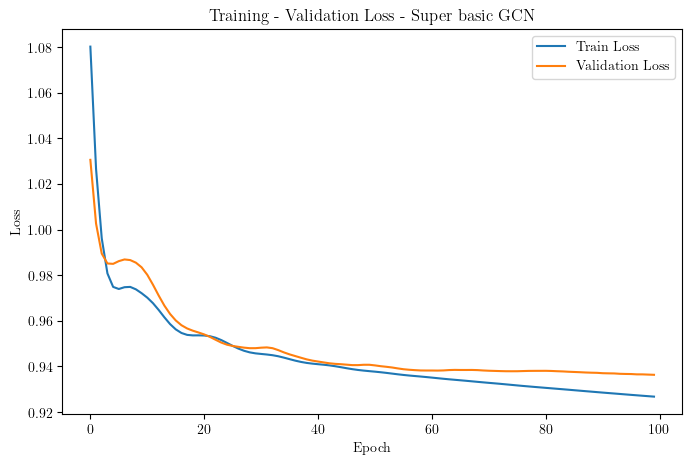

In [25]:
best_gcn_sb_model, train_losses, val_losses, training_time1 = train_model(
    model_class=GCN_super_basic,  
    model_name=list(model_names)[0],
    in_channels=node_features.shape[1],
    hidden_channels=128,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.01,
    weight_decay=1e-5,
    dropout=0.3
)

Epoch 0, Train Loss: 1.1194, Val Loss: 1.0289
Epoch 10, Train Loss: 0.9550, Val Loss: 0.9626
Epoch 20, Train Loss: 0.9372, Val Loss: 0.9383
Epoch 30, Train Loss: 0.9282, Val Loss: 0.9293
Epoch 40, Train Loss: 0.9196, Val Loss: 0.9208
Epoch 50, Train Loss: 0.9119, Val Loss: 0.9197
Epoch 60, Train Loss: 0.9052, Val Loss: 0.9132
Epoch 70, Train Loss: 0.9005, Val Loss: 0.9123
Epoch 80, Train Loss: 0.8974, Val Loss: 0.9107
Epoch 90, Train Loss: 0.8947, Val Loss: 0.9132
Model: GCN_basic
Training Time: 0.46s


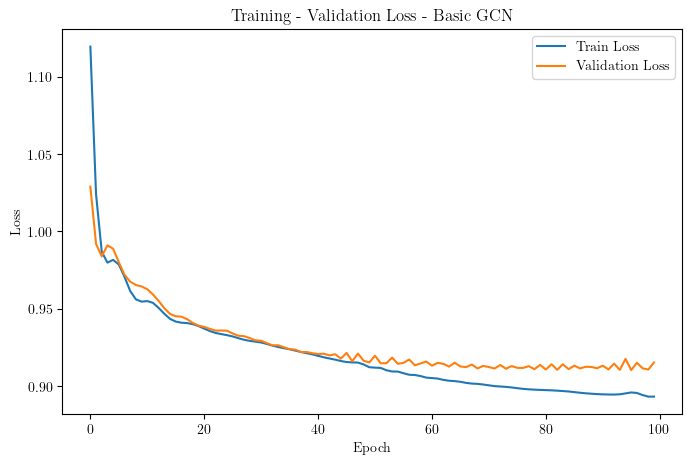

In [26]:
best_gcn_b_model, train_losses, val_losses, training_time2 = train_model(
    model_class=GCN_basic, 
    model_name=list(model_names)[1],
    in_channels=node_features.shape[1],
    hidden_channels=64,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.01,
    weight_decay=1e-4,
    dropout=0.5
)

Epoch 0, Train Loss: 1.1102, Val Loss: 1.0189
Epoch 10, Train Loss: 0.9529, Val Loss: 0.9552
Epoch 20, Train Loss: 0.9351, Val Loss: 0.9347
Epoch 30, Train Loss: 0.9237, Val Loss: 0.9229
Epoch 40, Train Loss: 0.9153, Val Loss: 0.9159
Epoch 50, Train Loss: 0.9081, Val Loss: 0.9135
Epoch 60, Train Loss: 0.9017, Val Loss: 0.9132
Epoch 70, Train Loss: 0.8972, Val Loss: 0.9092
Epoch 80, Train Loss: 0.8936, Val Loss: 0.9090
Epoch 90, Train Loss: 0.8908, Val Loss: 0.9108
Model: GCN
Training Time: 0.47s


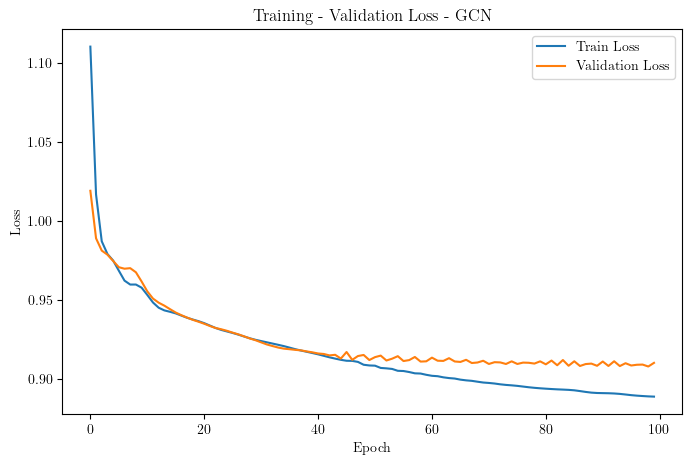

In [27]:
best_gcn_model, train_losses, val_losses, training_time3 = train_model(
    model_class=GCN,  
    model_name=list(model_names)[2],
    in_channels=node_features.shape[1],
    hidden_channels=64,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.01,
    weight_decay=1e-5,
    dropout=0
)

Epoch 0, Train Loss: 1.1027, Val Loss: 1.0796
Epoch 10, Train Loss: 0.9941, Val Loss: 1.0054
Epoch 20, Train Loss: 0.9807, Val Loss: 0.9978
Epoch 30, Train Loss: 0.9754, Val Loss: 0.9930
Epoch 40, Train Loss: 0.9689, Val Loss: 0.9787
Epoch 50, Train Loss: 0.9621, Val Loss: 0.9720
Epoch 60, Train Loss: 0.9523, Val Loss: 0.9604
Epoch 70, Train Loss: 0.9394, Val Loss: 0.9473
Epoch 80, Train Loss: 0.9279, Val Loss: 0.9410
Epoch 90, Train Loss: 0.9187, Val Loss: 0.9339
Model: GAT
Training Time: 0.92s


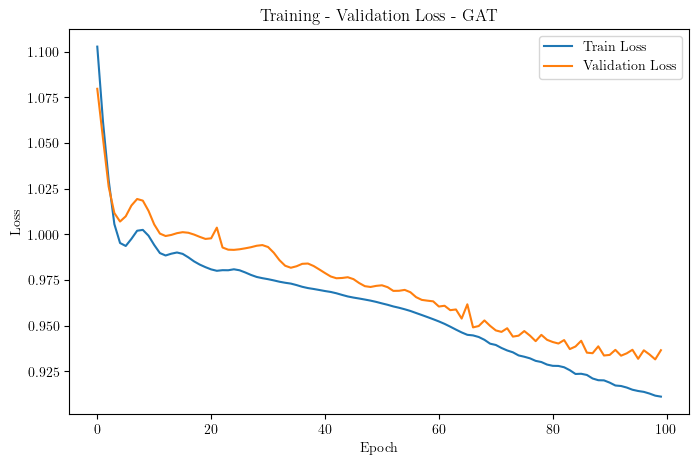

In [28]:
best_gat_model, train_losses, val_losses, training_time4 = train_model(
    model_class=GAT,  
    model_name=list(model_names)[3],
    in_channels=node_features.shape[1],
    hidden_channels=32,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=100,
    lr=0.005,
    weight_decay=1e-4,
    dropout=0
)

Epoch 0, Train Loss: 1.0924, Val Loss: 1.1245
Epoch 10, Train Loss: 0.9779, Val Loss: 0.9840
Epoch 20, Train Loss: 0.9639, Val Loss: 0.9726
Epoch 30, Train Loss: 0.9439, Val Loss: 0.9574
Epoch 40, Train Loss: 0.9366, Val Loss: 0.9499
Epoch 50, Train Loss: 0.9259, Val Loss: 0.9455
Epoch 60, Train Loss: 0.9148, Val Loss: 0.9416
Epoch 70, Train Loss: 0.9119, Val Loss: 0.9393
Epoch 80, Train Loss: 0.9018, Val Loss: 0.9425
Epoch 90, Train Loss: 0.9081, Val Loss: 0.9436
Epoch 100, Train Loss: 0.9021, Val Loss: 0.9378
Epoch 110, Train Loss: 0.8944, Val Loss: 0.9359
Epoch 120, Train Loss: 0.8999, Val Loss: 0.9432
Epoch 130, Train Loss: 0.8995, Val Loss: 0.9458
Epoch 140, Train Loss: 0.8875, Val Loss: 0.9378
Epoch 150, Train Loss: 0.8901, Val Loss: 0.9402
Epoch 160, Train Loss: 0.8854, Val Loss: 0.9400
Epoch 170, Train Loss: 0.8786, Val Loss: 0.9318
Epoch 180, Train Loss: 0.8819, Val Loss: 0.9299
Epoch 190, Train Loss: 0.8782, Val Loss: 0.9400
Model: GraphSAGE
Training Time: 0.79s


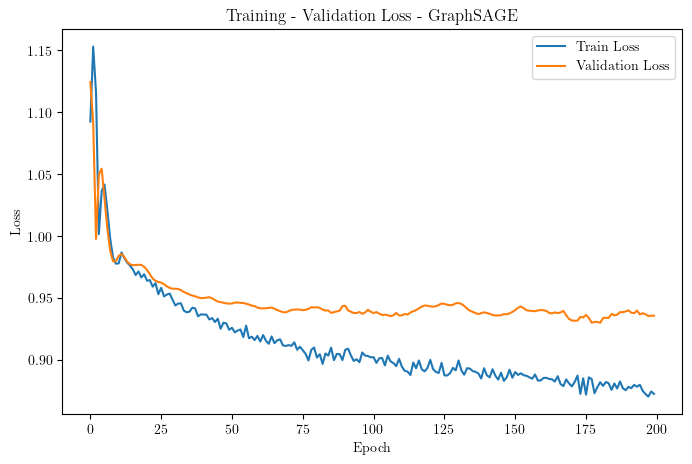

In [32]:
best_sage_model, train_losses, val_losses, training_time5 = train_model(
    model_class=GraphSAGE,  
    model_name=list(model_names)[4],
    in_channels=node_features.shape[1],
    hidden_channels=128,
    out_channels=3,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    train_mask=train_mask,
    val_mask=val_mask,
    device=device,
    num_epochs=200,
    lr=0.01,
    weight_decay=1e-5,
    dropout=0.5
)

In [30]:
training_times = [
    {"Model": list(model_names)[0], "Training Time (seconds)": training_time1},
    {"Model": list(model_names)[1], "Training Time (seconds)": training_time2},
    {"Model": list(model_names)[2], "Training Time (seconds)": training_time3},
    {"Model": list(model_names)[3], "Training Time (seconds)": training_time4},
    {"Model": list(model_names)[4], "Training Time (seconds)": training_time5}
]

# Convert to DataFrame
training_times_df = pd.DataFrame(training_times)

# Save to CSV
training_times_df.to_csv('../03_plots/content_agnostic/training_times.csv', index=False)

## 05 Hyperparameter Tuning

In [31]:
from sklearn.model_selection import ParameterGrid
from torch.optim import Adam

param_grid = {
    "hidden_size": [32, 64, 128],
    "dropout": [0, 0.3, 0.5],
    "learning_rate": [0.01, 0.005, 0.001],
    "weight_decay": [1e-5, 1e-4, 1e-3]
}

# Get all parameter combinations
param_grid = list(ParameterGrid(param_grid))

In [47]:
def train_and_tune_model(model_class, param_grid, node_features, edge_index, labels,
                         train_mask, val_mask, device, class_weights,
                         latex_results_dict, edge_attr=None):
    best_model = None
    best_params = None
    best_val_loss = float("inf")

    node_features = node_features.to(device)
    edge_index = edge_index.to(device)
    labels = labels.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)

    model_name = model_class.__name__
    
    for params in param_grid:
        train_losses, val_losses = [], []

        model = model_class(
            in_channels=node_features.shape[1], 
            hidden_channels=params["hidden_size"], 
            out_channels=3, 
            dropout=params["dropout"]
        ).to(device)

        optimizer = Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
        criterion = torch.nn.CrossEntropyLoss()  # weight=class_weights

        num_epochs = 100
        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            out = model(node_features, edge_index)
            loss = criterion(out[train_mask], labels[train_mask])
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

            model.eval()
            with torch.no_grad():
                val_out = model(node_features, edge_index)
                val_loss = criterion(val_out[val_mask], labels[val_mask])
            val_losses.append(val_loss.item())

        if val_loss < best_val_loss:
            best_val_loss = val_loss.item()
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_model = model
            best_params = params

            torch.save(best_model.state_dict(), f'../03_plots/content_agnostic/best_{model_name}.pth')

    # Plot Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(best_train_losses, label="Train Loss")
    plt.plot(best_val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f'Training - Validation Loss - {model_name}')
    plt.savefig(f'../03_plots/content_agnostic/train_val_{model_name}.png')
    plt.show()

    print("Best Hyperparameters:", best_params)
    print("Best Validation Loss:", best_val_loss)

    # Append results to shared LaTeX dictionary
    best_params_with_loss = best_params.copy()
    best_params_with_loss["val_loss"] = round(best_val_loss, 4)
    latex_results_dict[model_name] = best_params_with_loss

    return best_model, best_params, best_val_loss

In [48]:
def export_latex_table(latex_results_dict, filename='best_hyperparameters_content_agnostic.tex'):
    # Collect all unique hyperparameter names across models
    all_keys = set()
    for params in latex_results_dict.values():
        all_keys.update(params.keys())
    all_keys = sorted(all_keys)

    # Start LaTeX table
    latex = "\\begin{table}[h!]\n\\centering\n"
    latex += "\\caption{Best Hyperparameters for All Models}\n"
    latex += "\\begin{tabular}{l" + " c" * len(all_keys) + "}\n"
    latex += "\\toprule\n"
    latex += "Model & " + " & ".join(all_keys) + " \\\\\n"
    latex += "\\midrule\n"

    for model, params in latex_results_dict.items():
        row = [model] + [str(params.get(key, "-")) for key in all_keys]
        latex += " & ".join(row) + " \\\\\n"

    latex += "\\bottomrule\n"
    latex += "\\end{tabular}\n"
    latex += "\\end{table}\n"

    with open(f'../03_plots/content_agnostic/{filename}', 'w') as f:
        f.write(latex)


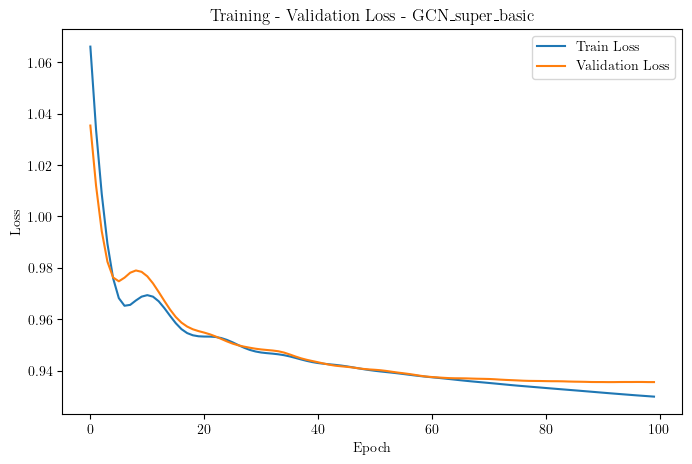

Best Hyperparameters: {'dropout': 0, 'hidden_size': 64, 'learning_rate': 0.01, 'weight_decay': 0.0001}
Best Validation Loss: 0.9354897141456604


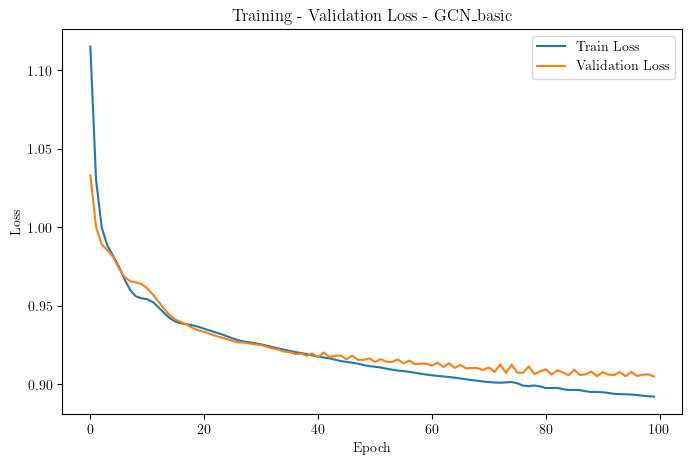

Best Hyperparameters: {'dropout': 0.5, 'hidden_size': 128, 'learning_rate': 0.005, 'weight_decay': 0.0001}
Best Validation Loss: 0.9050369262695312


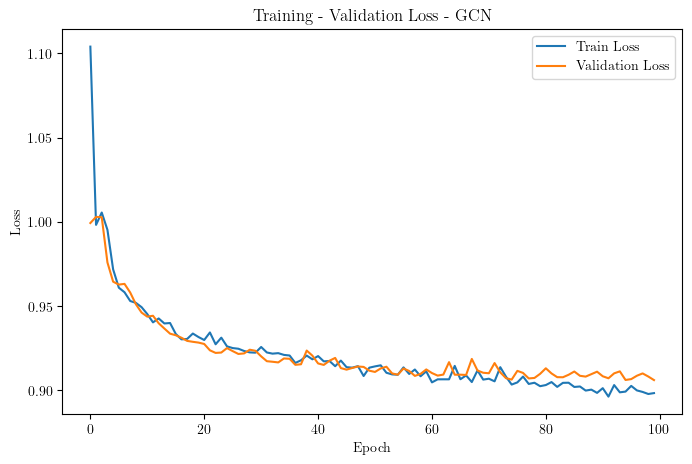

Best Hyperparameters: {'dropout': 0.3, 'hidden_size': 128, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Best Validation Loss: 0.9060752987861633


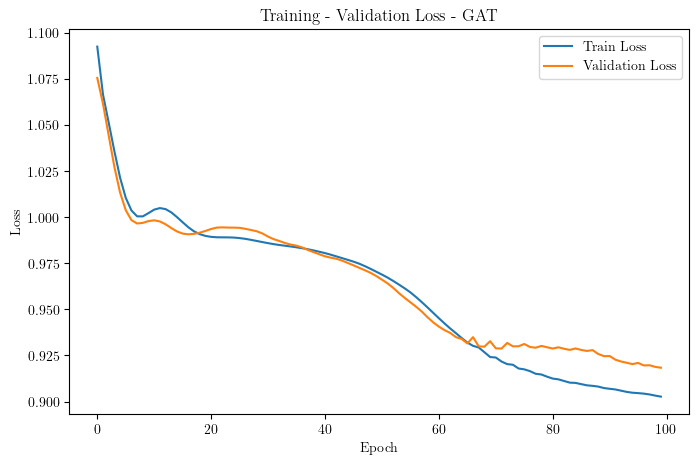

Best Hyperparameters: {'dropout': 0, 'hidden_size': 128, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Best Validation Loss: 0.9183215498924255


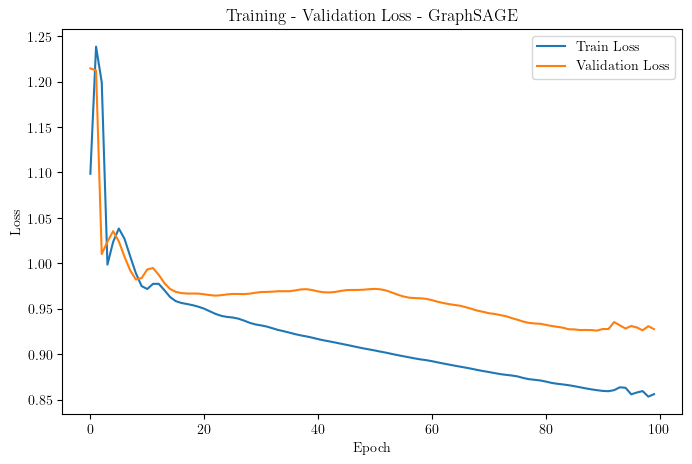

Best Hyperparameters: {'dropout': 0, 'hidden_size': 128, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Best Validation Loss: 0.9277446269989014


In [49]:
latex_results = {}

for model_class in [GCN_super_basic, GCN_basic, GCN, GAT, GraphSAGE]:
    train_and_tune_model(
        model_class, param_grid, node_features, edge_index, labels,
        train_mask, val_mask, device, class_weights,
        latex_results
    )

# Export the combined LaTeX table
export_latex_table(latex_results)


## 06 Evaluation

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

def evaluate_models(models, node_features, edge_index, labels, val_mask, device):
    results = []

    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, val_mask = labels.to(device), val_mask.to(device)

    for model_name, model in models.items():
        model.eval()
        with torch.no_grad():
            #if model == best_gat_attr_model or model == model_SAGEatttr:
                #out = model(node_features, edge_index, edge_attr)
            #else:
            out = model(node_features, edge_index)
            pred = out.argmax(dim=1)

        # Convert tensors to numpy for metric calculations
        y_true = labels[val_mask].cpu().numpy()
        y_pred = pred[val_mask].cpu().numpy()

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")

        print(f"Model: {model_name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("\nClassification Report:\n", classification_report(y_true, y_pred))

        # Confusion Matrix
        conf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(conf_matrix) #, display_labels=["Class 0", "Class 1", "Class 2"]
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {model_name} (content agnostic)")
        plt.savefig(f'../03_plots/content_agnostic/con_matrix_{model_name}.png')
        plt.show()

        # Store results
        results.append({"Model": model_name, "Accuracy": accuracy, "F1-Score": f1})

    # Convert results to DataFrame and display
    results_df = pd.DataFrame(results)
    results_df.to_csv('../03_plots/content_agnostic/results_content_agnostic.csv', index=False)
    
    return results_df


Model: Super basic GCN
Accuracy: 0.4974
F1-Score: 0.4806

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.12      0.19       141
           1       0.46      0.62      0.52       420
           2       0.57      0.50      0.54       416

    accuracy                           0.50       977
   macro avg       0.48      0.41      0.42       977
weighted avg       0.50      0.50      0.48       977



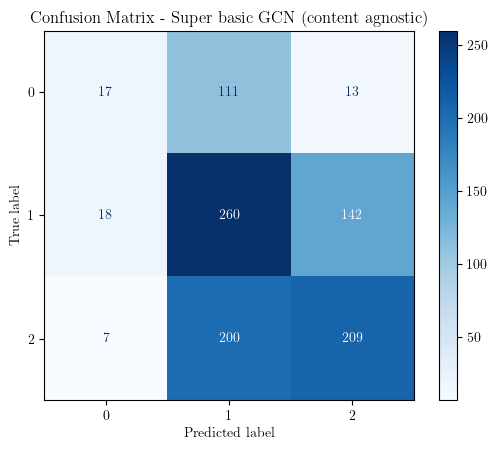

Model: Basic GCN
Accuracy: 0.5220
F1-Score: 0.5103

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.21      0.27       141
           1       0.48      0.70      0.57       420
           2       0.67      0.44      0.53       416

    accuracy                           0.52       977
   macro avg       0.51      0.45      0.46       977
weighted avg       0.54      0.52      0.51       977



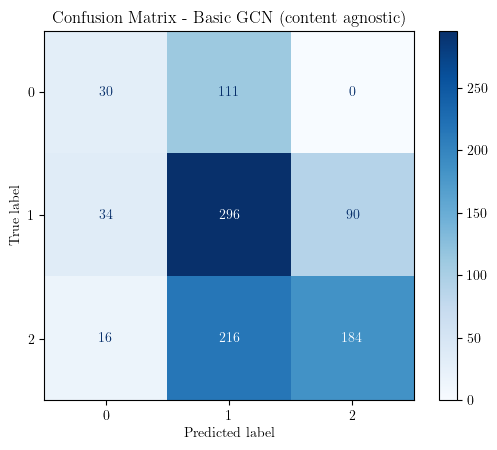

Model: GCN
Accuracy: 0.5302
F1-Score: 0.5192

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.21      0.28       141
           1       0.48      0.70      0.57       420
           2       0.66      0.47      0.55       416

    accuracy                           0.53       977
   macro avg       0.52      0.46      0.47       977
weighted avg       0.55      0.53      0.52       977



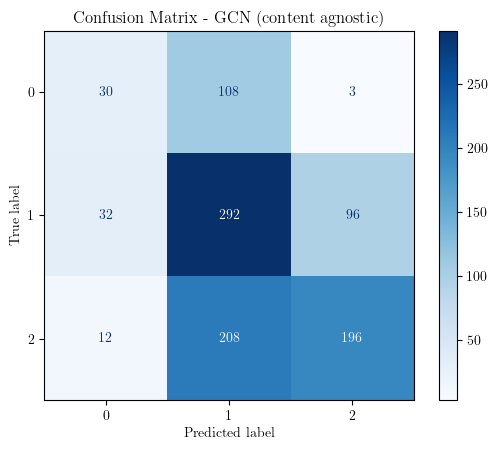

Model: GAT
Accuracy: 0.5220
F1-Score: 0.5096

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.18      0.27       141
           1       0.49      0.56      0.52       420
           2       0.56      0.60      0.58       416

    accuracy                           0.52       977
   macro avg       0.53      0.45      0.46       977
weighted avg       0.52      0.52      0.51       977



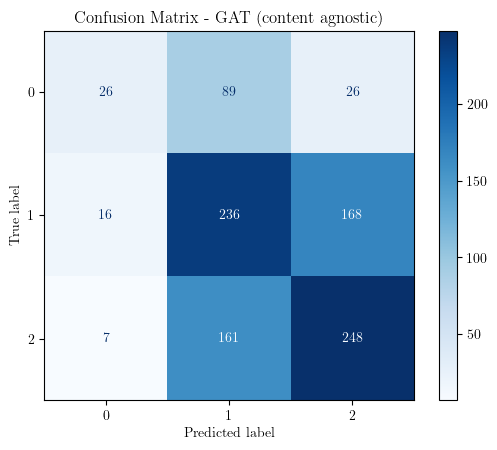

Model: GraphSAGE
Accuracy: 0.5292
F1-Score: 0.5193

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.21      0.28       141
           1       0.48      0.54      0.51       420
           2       0.60      0.63      0.61       416

    accuracy                           0.53       977
   macro avg       0.50      0.46      0.47       977
weighted avg       0.52      0.53      0.52       977



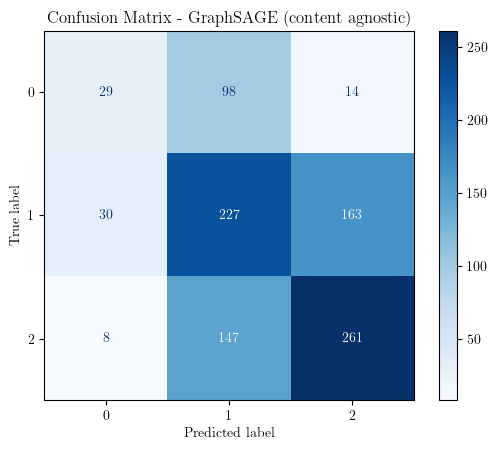

In [38]:
# Define models to evaluate
models_to_compare = {
    "Super basic GCN": best_gcn_sb_model,
    "Basic GCN": best_gcn_b_model,
    "GCN": best_gcn_model,
    "GAT": best_gat_model,
    "GraphSAGE": best_sage_model
}

# Run evaluation on all models
evaluation_results = evaluate_models(
    models=models_to_compare, 
    node_features=node_features, 
    edge_index=edge_index, 
    labels=labels, 
    val_mask=val_mask, 
    device=device
)


## 07 Testing

In [39]:
test_mask = torch.tensor(test_data['domain_id'].values, dtype=torch.bool)

In [40]:
# test labels
pc1_values = test_data['pc1']
test_labels = pd.cut(pc1_values, bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
test_labels = torch.tensor(test_labels.values, dtype=torch.long)

In [41]:
# Safe fallback if domain_id isn't correct
test_indices = test_data.index.to_numpy()

# Make sure all test indices are valid
assert test_indices.max() < labels.shape[0], "Test indices exceed label size"

test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
test_mask[test_indices] = True


In [42]:
test_indices = test_data['domain_id'].to_numpy()
#test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
#test_mask[test_indices] = True

test_mask = torch.zeros(labels.shape[0], dtype=torch.bool)
test_mask[test_data.index.to_numpy()] = True

In [54]:
def test_models_on_test_set(models, node_features, edge_index, labels, test_mask, device):
    results = []

    node_features, edge_index = node_features.to(device), edge_index.to(device)
    labels, test_mask = labels.to(device), test_mask.to(device)

    for model_name, model in models.items():
        model.eval()
        with torch.no_grad():
            out = model(node_features, edge_index)
            pred = out.argmax(dim=1)

        y_true = labels[test_mask].cpu().numpy()
        y_pred = pred[test_mask].cpu().numpy()

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        class_report = classification_report(y_true, y_pred, output_dict=True)

        precision = class_report['weighted avg']['precision']
        recall = class_report['weighted avg']['recall']

        print(f"Model: {model_name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("\nClassification Report:\n", classification_report(y_true, y_pred))

        # Confusion Matrix
        conf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(conf_matrix)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {model_name} (content agnostic)")
        plt.savefig(f'../03_plots/content_agnostic/con_matrix_{model_name}.png')
        plt.show()

        # Store metrics
        results.append({
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4)
        })

        # Save classification report
        with open(f'../03_plots/content_agnostic/classification_report_{model_name}.txt', 'w') as f:
            f.write(classification_report(y_true, y_pred))

    # Save CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv('../03_plots/content_agnostic/results_test.csv', index=False)

    # Export LaTeX table
    latex_table = results_df.to_latex(index=False, float_format="%.4f",
                                      caption="Evaluation Metrics on Test Set",
                                      label="tab:test_results",
                                      column_format="lcccc",
                                      bold_rows=False,
                                      longtable=False,
                                      escape=False)
    # Add \toprule etc. formatting
    latex_table = latex_table.replace("\\toprule", "\\toprule").replace("\\midrule", "\\midrule").replace("\\bottomrule", "\\bottomrule")

    with open('../03_plots/content_agnostic/results_test.tex', 'w') as f:
        f.write(latex_table)

    return results_df

Model: Super basic GCN
Accuracy: 0.4877
F1-Score: 0.4683

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.14      0.21       195
           1       0.46      0.65      0.54       533
           2       0.55      0.45      0.49       494

    accuracy                           0.49      1222
   macro avg       0.48      0.41      0.41      1222
weighted avg       0.49      0.49      0.47      1222



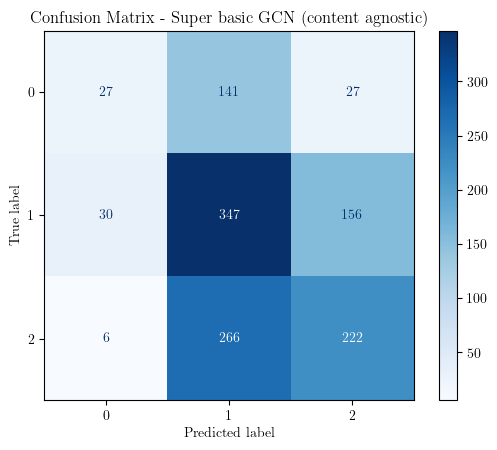

Model: Basic GCN
Accuracy: 0.4853
F1-Score: 0.4550

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.24      0.30       195
           1       0.46      0.77      0.57       533
           2       0.64      0.28      0.39       494

    accuracy                           0.49      1222
   macro avg       0.50      0.43      0.42      1222
weighted avg       0.52      0.49      0.45      1222



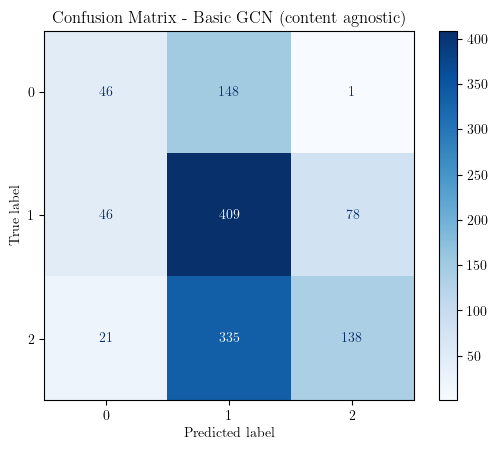

Model: GCN
Accuracy: 0.4967
F1-Score: 0.4727

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.23      0.30       195
           1       0.46      0.75      0.57       533
           2       0.63      0.33      0.43       494

    accuracy                           0.50      1222
   macro avg       0.51      0.44      0.43      1222
weighted avg       0.53      0.50      0.47      1222



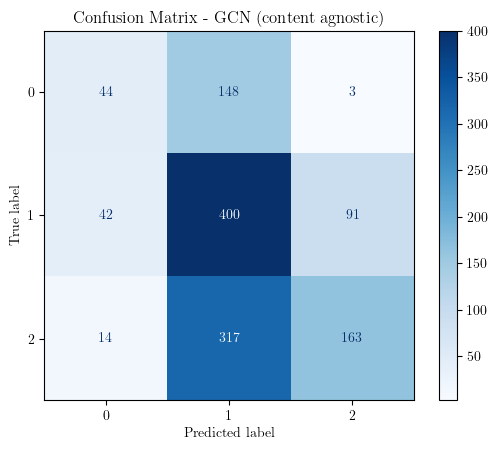

Model: GAT
Accuracy: 0.4992
F1-Score: 0.4766

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.15      0.23       195
           1       0.47      0.70      0.56       533
           2       0.56      0.42      0.48       494

    accuracy                           0.50      1222
   macro avg       0.52      0.42      0.43      1222
weighted avg       0.52      0.50      0.48      1222



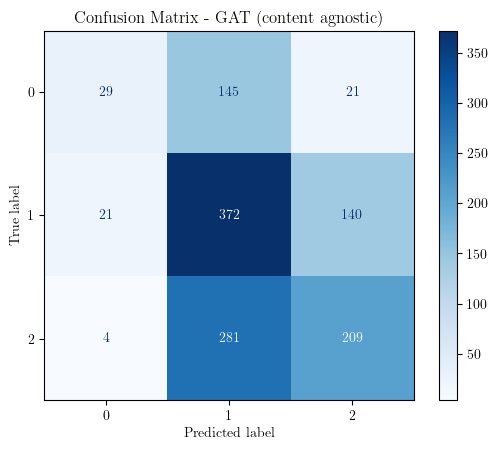

Model: GraphSAGE
Accuracy: 0.5311
F1-Score: 0.5196

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.22      0.30       195
           1       0.49      0.64      0.56       533
           2       0.60      0.53      0.57       494

    accuracy                           0.53      1222
   macro avg       0.53      0.46      0.47      1222
weighted avg       0.54      0.53      0.52      1222



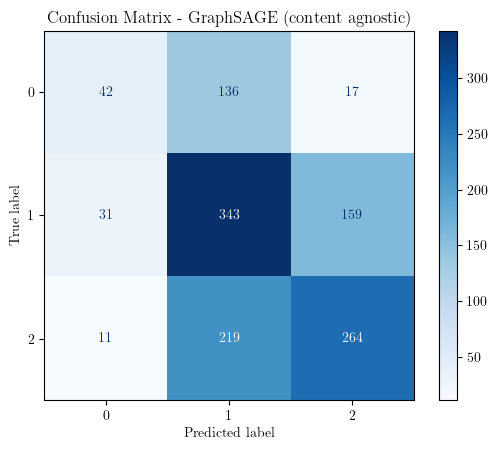

In [55]:
test_results = test_models_on_test_set(
    models=models_to_compare,
    node_features=node_features,
    edge_index=edge_index,
    labels=labels,
    test_mask=test_mask,  # Define this accordingly
    device=device
)
